# Resúmenes: Fundamentos Matemáticos de Machine Learning

Chuletas de repaso rápido de los notebooks [*1: Introducción al Álgebra Lineal*](1-intro-to-linear-algebra.ipynb), [*2: Álgebra Lineal II*](2-linear-algebra-ii.ipynb) y [*3: Cálculo I*](3-calculus-i.ipynb) y [*4: Cálculo II*](4-calculus-ii.ipynb) de la serie *Fundamentos Matemáticos de Machine Learning*. Cada bloque incluye un ejemplo concreto con números reales, sacado directamente del notebook correspondiente — para la teoría y el desarrollo completo, consulta cada notebook original.

## Notebook 1: Introducción al Álgebra Lineal

### Los objetos básicos

Un **escalar** es un solo número. Un **vector** es una lista de números. Una **matriz** es una tabla de números (filas y columnas). En ML se les llama a los tres «tensores», de rango 0, 1 y 2 — «rango» aquí solo significa cuántas dimensiones tiene la tabla.

**Transponer** una matriz ($X^T$) es simplemente girarla: lo que era fila pasa a ser columna.

**Ejemplo**: el vector $x=[25,2,5]$ es una lista de 3 números. La matriz $X$ de abajo tiene 3 filas y 2 columnas:
$$X=\begin{bmatrix}25&2\\5&26\\3&7\end{bmatrix}$$

**Uso en ML**: así es como se representan los datos — un vector por observación (fila), una matriz para todo el dataset, y tablas con más dimensiones (tensores) para cosas como imágenes o vídeo.

**En Python**:

In [2]:
import numpy as np

x = np.array([25, 2, 5])
X = np.array([[25, 2], [5, 26], [3, 7]])
x.shape, X.shape

((3,), (3, 2))

### Normas (miden el «tamaño» de un vector)

Una **norma** es, sencillamente, la longitud de un vector — no importa hacia dónde apunte, solo cuánto mide.

* **$L^1$**: suma los valores absolutos de cada número. Útil para distinguir «exactamente 0» de «casi 0» (regularización Lasso).
* **$L^2$** (la más habitual): la distancia en línea recta desde el origen — como medir con una regla. Si alguien dice «la norma» sin más, casi siempre se refiere a esta.
* **$L^2$ al cuadrado**: lo mismo, pero sin la raíz cuadrada — más rápida de calcular; aparece en el error cuadrático medio (MSE) y en Ridge.
* **$L^\infty$**: el número más grande (en valor absoluto) del vector, sin más.
* **Norma de Frobenius**: la misma idea que $L^2$, pero para una matriz entera en vez de un vector.

**Ejemplo**, con $x=[25,2,5]$: $L^1=32$, $L^2\approx25{,}6$, $L^2$ al cuadrado $=654$, $L^\infty=25$.

**Uso en ML**: las normas son el ingrediente clave de la regularización — una penalización que se suma al error para evitar el sobreajuste, castigando pesos demasiado grandes:

$$ \text{coste regularizado} = \text{error} + \lambda \cdot \text{norma}(w) $$

* **Lasso** usa $L^1$ ($\lambda\sum_i|w_i|$): tiende a llevar algunos pesos a **exactamente 0**, eliminándolos del modelo por completo. En la práctica hace **selección automática de *features*** — muy útil cuando sospechas que solo unas pocas variables importan de verdad entre muchas.
* **Ridge** usa $L^2$ al cuadrado ($\lambda\sum_i w_i^2$): encoge **todos** los pesos hacia 0 de forma suave, pero casi nunca los deja en 0 exacto. Funciona especialmente bien cuando las variables están **correlacionadas** entre sí (reparte el «peso» entre ellas en vez de depender de una sola).
* $\lambda$ controla cuánto pesa la penalización: $\lambda=0$ es no regularizar nada; cuanto mayor, más se fuerza a los pesos a encogerse.

(El MSE, por cierto, también es una norma: la $L^2$ al cuadrado, pero aplicada al vector de errores en vez de a los pesos.)

**En Python**:

In [1]:
x = np.array([25, 2, 5])
np.linalg.norm(x, 1), np.linalg.norm(x, 2), np.linalg.norm(x, np.inf)

(32.0, 25.573423705088842, 25.0)

### Vectores especiales

* **Vector nulo**: puros ceros. Sumarlo a otro vector no cambia nada.
* **Ortogonales**: dos vectores forman un ángulo de 90° (son perpendiculares). Se detecta calculando su producto escalar: si da 0, son ortogonales.
* **Ortonormales**: ortogonales, y además cada uno mide exactamente 1 (la longitud se saca con la norma).
* **Base**: el conjunto mínimo de vectores que, combinándolos, permite construir cualquier otro vector de ese espacio.

**Ejemplo**: $i=[1,0]$ y $j=[0,1]$ son ortonormales — su producto escalar es 0 y ambos miden 1. Ademas tambien son base porque si multiplicas porque puedes crear el vector $[4,2]$ como multiplicar por 4 el vector i y 2 el vector j

**Uso en ML**: tener los datos expresados en una base ortonormal (direcciones que no se pisan entre sí) es justo lo que consiguen PCA y SVD.

**En Python**:

In [1]:
i = np.array([1, 0])
j = np.array([0, 1])
np.dot(i, j)  # 0 -> ortogonales

np.int64(0)

### Operaciones con matrices

* **Multiplicar/sumar por un número**: se aplica a cada elemento de la tabla, uno a uno.
* **Producto de Hadamard**: multiplicar dos matrices (del mismo tamaño) elemento a elemento — no es «la multiplicación de matrices» de verdad.
* **Producto escalar** (entre dos vectores): multiplica cada pareja de números y suma los resultados; el resultado es un único número.
* **Matriz por vector, o matriz por matriz**: la multiplicación «de verdad». Importante: el orden importa — $AB$ no es lo mismo que $BA$.

**Ejemplo**: en una neurona artificial, calcular $z=w\cdot x+b$ es justo un producto escalar más un número.

**Uso en ML**: el producto escalar es la operación que ejecuta cada neurona de una red, millones de veces; la multiplicación matriz×matriz es cómo una capa entera procesa un lote completo de datos a la vez, en paralelo.

**En Python**:

In [1]:
A = np.array([[3, 4], [5, 6], [7, 8]])
b = np.array([1, 2])
A @ b   # matriz por vector

array([11, 17, 23])

In [ ]:
A = np.array([[3, 4], [5, 6], [7, 8]])
A*A # hadamard product

array([[ 9, 16],
       [25, 36],
       [49, 64]])

### Matrices especiales

* **Identidad**: la matriz que «no hace nada» — multiplicar por ella deja cualquier vector exactamente igual.
* **Simétrica**: si la giras (la transpones), queda idéntica.
* **Diagonal**: todo son ceros salvo la diagonal — muy rápida de multiplicar e invertir.
* **Ortogonal**: sus columnas son perpendiculares entre sí y miden 1 (es decir sus columnas son ortonormales). Su ventaja: invertirla es tan fácil como girarla.

**Ejemplo**: la matriz de rotación de 90°, $Q=\begin{bmatrix}0&-1\\1&0\end{bmatrix}$, es ortogonal — al rotar un vector con ella, su longitud no cambia (con $v=[3,4]$, antes y después mide 5).

**Uso en ML**: las matrices ortogonales son las $Q$/$U$/$V$ que salen al descomponer una matriz de covarianza — por eso PCA funciona.

**En Python**:

In [1]:
np.eye(3)   # matriz identidad

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

### Inversión y sistemas lineales

* La **inversa** de una matriz $A$ es la matriz que «deshace» lo que hace $A$ — multiplicadas juntas dan la identidad. Solo existe si $A$ es cuadrada y no tiene columnas redundantes.
* Sirve para despejar incógnitas: de $Xw=y$ se saca $w=X^{-1}y$.
* En la práctica casi nunca hay una solución exacta (más datos que incógnitas) — se usa en su lugar la **ecuación normal**, que encuentra los pesos que, en promedio, menos error cometen.

**Ejemplo real** (regresión de precios de casas): con datos de 8 casas, la ecuación normal da unos pesos que, para una casa de 120 m² y 4 habitaciones, predicen $\approx305$ mil €.

**Uso en ML**: la ecuación normal es la forma «cerrada» (sin iterar) de entrenar una regresión lineal — la alternativa exacta al descenso de gradiente cuando el problema es pequeño y está bien condicionado.

**En Python**:

In [1]:
X = np.array([[4, 2], [-5, -3]])
y = np.array([4, -7])
w = np.linalg.inv(X) @ y   # resolver Xw = y
w

array([-1.,  4.])

## Notebook 2: Álgebra Lineal II

### Transformaciones lineales y vectores propios

* Multiplicar un vector por una matriz lo **transforma**: puede rotarlo, estirarlo o encogerlo.
* Un **vector propio** es una dirección especial que la matriz no rota — solo la estira o encoge. El **valor propio** es cuánto (el factor de escala): $Av=\lambda v$.
* Una matriz $n\times n$ tiene hasta $n$ pares (vector propio, valor propio).
* Cuidado en el código: `np.linalg.eig()` devuelve primero los valores propios y después los vectores propios — fácil de confundir; y $V$ (mayúscula) son los **vectores** propios, no los «valores» (a pesar de la letra).

**Ejemplo**: para una matriz $A$ concreta, uno de sus vectores propios apunta en la dirección $[0{,}86,\,0{,}51]$, y esa dirección se estira $\times1{,}37$ al aplicar $A$ — comprobado con $Av=\lambda v$.

**Uso en ML**: aplicar esto a la matriz de covarianza de un dataset es, literalmente, **PCA** — los vectores propios son las direcciones más importantes de los datos.

**En Python**:

In [ ]:
A = np.array([[-1, 4], [2, -2]])
lambdas, V = np.linalg.eig(A)   # lambdas primero, V (vectores) después

v = V[:, 0]              # primer vector propio (primera columna)
print('lambda:', lambdas[0].real)
print('A @ v:      ', (A @ v).real)
print('lambda * v: ', (lambdas[0] * v).real)   # debe coincidir con A @ v
# es decir multiplicar el vector propio 0 por su valor propio 0 da lo mismo que multiplicar la matriz por el vector propio 0 y asi para todos los vectores y valores propios. Esto es lo que significa la ecuación Av = λv.

lambda: 1.3722813232690143
A @ v:       [1.18031462 0.70000958]
lambda * v:  [1.18031462 0.70000958]


### Determinante

* El **determinante** es un solo número que dice cuánto «estira o encoge el espacio» una matriz (el área en 2D, el volumen en 3D).
* Si el determinante es 0, la matriz «aplasta» el espacio — se pierde información sin remedio, y por eso no tiene inversa.
* Truco: el determinante es igual a multiplicar todos los valores propios entre sí.

**Ejemplo**: una matriz con determinante $\approx20$ tiene 3 valores propios que, multiplicados entre sí, también dan $\approx20$.

**Uso en ML**: comprobar que el determinante de $X^TX$ no es 0 es lo que garantiza que una regresión tenga solución — si da 0, hay *features* redundantes en los datos.

**En Python**:

In [1]:
np.linalg.det(np.array([[4, 2], [-5, -3]]))

-2.0000000000000013

### Descomposición propia

* Cualquier matriz cuadrada se puede «descomponer» en sus vectores y valores propios, y reconstruirla multiplicándolos de vuelta.
* Si la matriz es simétrica, esta descomposición es especialmente barata y estable de calcular.
* **¿Para qué sirve?** Con la matriz ya descompuesta, operaciones complicadas (como elevarla a una potencia) se vuelven triviales — y es la base matemática de **PCA**.

**Ejemplo**: para una matriz simétrica sencilla, sus valores propios son $3$ y $1$, y la matriz de vectores propios resulta ser ortogonal, como se espera.

**Uso en ML**: es el paso matemático exacto que hay detrás de PCA — descomponer la matriz de covarianza de un dataset en sus direcciones principales.

**En Python**:

In [ ]:
A = np.array([[4, 2], [-5, -3]])
lambdas, V = np.linalg.eig(A)
Lambda = np.diag(lambdas)
reconstruida = V @ Lambda @ np.linalg.inv(V) # si es simetrica valdria con la transpuesta de V en vez de la inversa
print(np.round(reconstruida.real, 4))   # debe coincidir con A

[[ 4.  2.]
 [-5. -3.]]


### SVD y Pseudoinversa

* La **SVD** es como la descomposición anterior, pero funciona con **cualquier** matriz, aunque no sea cuadrada.
* La **pseudoinversa** es el equivalente de «la inversa» para matrices que no tienen una inversa de verdad — muy útil para resolver una regresión cuando no hay solución exacta.
* La **traza** es simplemente sumar los números de la diagonal de una matriz.

**Ejemplo real**: en una regresión con datos reales, `w = np.linalg.pinv(X) @ y` ajusta la recta directamente, sin necesitar que $X^TX$ tenga inversa.

**Uso en ML**: la SVD es la base de la compresión de imágenes, de los sistemas de recomendación (factorización de matrices) y, junto con la pseudoinversa, de resolver regresiones cuando la matriz de datos no es cuadrada.

**En Python**:

In [5]:
A = np.array([[-1, 2], [3, -2], [5, 7]])   # matriz no cuadrada (3x2)
U, d, VT = np.linalg.svd(A)                # SVD
w = np.linalg.pinv(A) @ np.array([1, 2, 3])  # pseudoinversa, para resolver Aw≈y, aqui estamos haciendo la pseudoinversa por y para obtener los pesos w que minimizan la distancia entre Aw e y. Esto es útil cuando A no es cuadrada o no tiene inversa.
print('U:', U.shape, '| d:', d.shape, '| VT:', VT.shape)

U: (3, 3) | d: (2,) | VT: (2, 2)


`d` es un vector 1D (solo los valores singulares, sin los ceros de relleno) — para reconstruir $A$ hay que volver a montar la matriz diagonal $D$ con la forma de $A$ ($3\times2$, no $2\times2$):

In [6]:
D = np.zeros((3, 2))       # misma forma que A
D[:2, :2] = np.diag(d)     # los valores singulares van en la diagonal
reconstruida = U @ D @ VT
print(np.round(reconstruida, 4))   # debe coincidir con A

[[-1.  2.]
 [ 3. -2.]
 [ 5.  7.]]


In [7]:
D

array([[8.66918448, 0.        ],
       [0.        , 4.10429538],
       [0.        , 0.        ]])

Los 3 valores son las tres piezas que necesitas para reconstruir $A$ mediante $A = UDV^T$ (la misma fórmula que ya viste con la descomposición propia, pero válida para cualquier matriz, no solo las cuadradas):

U (matriz $m\times m$, aquí $3\times3$): los vectores singulares izquierdos — una base ortonormal del espacio de "salida" (filas de $A$).

d (aquí longitud 2, no una matriz): los valores singulares, ordenados de mayor a menor. NumPy te los da como un vector 1D por comodidad —no como la matriz diagonal $D$ completa— porque el resto de $D$ son ceros y sería desperdiciar memoria guardarlos.

VT (matriz $n\times n$, aquí $2\times2$): la transpuesta de los vectores singulares derechos — una base ortonormal del espacio de "entrada" (columnas de $A$).

Para qué sirve cada uno: exactamente lo mismo que en la descomposición propia — $U$ y $V$ son las "rotaciones" (entrada y salida), y los valores singulares en $d$ son "cuánto se estira" cada dirección al aplicar $A$. Como $A$ no es cuadrada aquí (pasa de 2 a 3 dimensiones), hacían falta dos bases distintas ($U$ para el espacio de llegada, $V$ para el de partida) en vez de una sola.

### PCA y aplicaciones reales

* **PCA** usa todo lo anterior para **reducir el número de columnas** de un dataset perdiendo la menor información posible: encuentra las direcciones en las que más varían los datos (los vectores propios de la matriz de covarianza) y se queda solo con las más importantes.
* La misma idea matemática (vectores y valores propios) reaparece en sitios muy distintos: reconocimiento facial, buscadores como Google, predicción del clima, ingeniería de estructuras, compresión de imágenes...

**Ejemplo real**: sobre el dataset Iris (150 flores, 4 medidas cada una), quedarse solo con 2 de esas direcciones conserva $\approx98\%$ de toda la información — y en ese espacio más pequeño, las 3 especies de flor quedan claramente separadas, aunque PCA nunca supo a qué especie pertenecía cada una.

**Uso en ML**: reducir dimensionalidad antes de entrenar un modelo (menos *features*, menos ruido, entrenamiento más rápido), visualizar datos de alta dimensión en 2D/3D, y comprimir información conservando lo esencial.

**En Python**:

In [1]:
from sklearn import datasets
from sklearn.decomposition import PCA

iris = datasets.load_iris()
pca = PCA(n_components=2)
X_reducido = pca.fit_transform(iris.data)   # de 4 columnas a 2
pca.explained_variance_ratio_

array([0.92461872, 0.05306648])

## Notebook 3: Cálculo I (Límites y Derivadas)

### Qué es el cálculo

* El **cálculo diferencial** (este notebook) mide **tasas de cambio** — con la herramienta de la **derivada**. El **cálculo integral** mide acumulación (áreas) — se ve en *Cálculo II*.
* En una frase: la derivada le dice a un modelo **en qué dirección** y **cuánto** ajustar cada uno de sus parámetros para equivocarse menos — es la base del descenso de gradiente, el método con el que se entrena prácticamente cualquier modelo de ML.

**Ejemplo**: no hay una fórmula única aquí — es el marco conceptual de todo lo que sigue en este notebook (límites, derivadas, reglas, autodiff), todo construido sobre la misma idea de «tasa de cambio».

**Uso en ML**: sin cálculo no hay descenso de gradiente — es, literalmente, el lenguaje matemático que permite que un modelo aprenda de los datos por sí solo, ajustando sus parámetros automáticamente.

### El concepto de límite

Un **límite** responde a una pregunta muy simple: **¿a qué valor se acerca una función a medida que te acercas a un punto?** No hace falta que la función esté definida exactamente en ese punto — solo importa la tendencia.

$$ \lim_{x \to a} f(x) = L $$

**Ejemplo**: la función $\frac{x^2-1}{x-1}$ no está definida en $x=1$ (división entre 0), pero según te acercas a $x=1$ desde ambos lados, se acerca cada vez más a **2** — ese es su límite ahí. En cambio, $\frac{25}{x}$ cerca de $x=0$ se dispara a $+\infty$ por un lado y a $-\infty$ por el otro — como no coinciden, decimos que ese límite **no existe**.

**Uso en ML**: los límites son la base formal de la derivada (y por tanto del descenso de gradiente); también aparecen al comprobar la estabilidad numérica de un modelo, por ejemplo evitando divisiones por cero en una función de activación.

**En Python** (con SymPy, matemática simbólica):

In [1]:
import sympy as sp
x = sp.symbols('x')
sp.limit((x**2 - 1)/(x - 1), x, 1)

2

### El método delta y la derivada

* **Pendiente**: cuánto sube o baja una recta (piensa en una carretera: cuesta arriba, llano, cuesta abajo).
* **Derivada**: la pendiente de una curva, pero medida en un único punto exacto (como la velocidad que marca el velocímetro de un coche en un instante, no la media del trayecto).
* **Método delta**: para hallar esa pendiente exacta, coges un segundo punto muy cercano y calculas la pendiente entre ambos; cuanto más cerca esté ese segundo punto, mejor se aproxima al valor real. Formalizado con un límite:
$$ \frac{dy}{dx} = \lim_{\Delta x \to 0} \frac{f(x+\Delta x) - f(x)}{\Delta x} $$

**Ejemplo**: para una parábola concreta, este método da una pendiente de 6 en un punto, y de 0 en otro (el punto más bajo de la curva, donde es totalmente plana).

**Uso en ML**: es la versión «a mano» de la diferenciación numérica — el mismo principio (probar un cambio muy pequeño y medir el efecto) que usa el *gradient checking*, una técnica para verificar que el autodiff de una librería calcula bien los gradientes.

**En Python**:

In [1]:
def f(x): return x**2 + 2*x + 2

delta = 1e-6
(f(2 + delta) - f(2)) / delta   # método delta: pendiente aproximada en x=2

6.000001000927568

### Las reglas de derivación

Existen unas cuantas reglas que permiten derivar funciones complicadas combinando derivadas ya conocidas, sin repetir el método delta cada vez (derivada de una constante, de una potencia, de una suma, de un producto, de un cociente...). En la práctica no hace falta aplicarlas a mano — Python ya las conoce.

**La regla de la cadena** merece mención aparte, porque es **la más importante para Machine Learning**: sirve para derivar una función «compuesta» (una función dentro de otra). Una red neuronal es exactamente eso — capas encadenadas — y aplicar esta regla capa a capa es lo que se llama **retropropagación**, el mecanismo que entrena redes neuronales.

**Ejemplo**: al combinar la regla de la cadena con la del producto sobre una función de prueba, se obtiene un resultado numérico ($550$ en un punto concreto) idéntico al que da Python automáticamente.

**Uso en ML**: la regla de la cadena, aplicada capa a capa, es literalmente el algoritmo de retropropagación que entrena cualquier red neuronal.

**En Python** (SymPy aplica las reglas automáticamente):

In [1]:
sp.diff(x**2 + 2*x + 2, x)

2*x + 2

### Diferenciación automática (autodiff)

Hay tres formas de obtener una derivada: **probar valores numéricos** (aproximada), **manipular la fórmula** (exacta, como en papel) y la **automática**: la que usan de verdad los frameworks de ML. Aquí la librería va anotando cada operación que haces (sumar, multiplicar...) formando un mapa interno, y cuando le pides la derivada, recorre ese mapa hacia atrás aplicando la regla de la cadena — sin que tú escribas ninguna fórmula.

En PyTorch, el patrón siempre es el mismo: creas un número, le dices que «lo vigile» (`requires_grad`), haces el cálculo normal, y llamas a `.backward()` para obtener la derivada en `.grad`.

**Y así es, literalmente, como se entrena un modelo**: calcular la predicción y el error (paso hacia delante) → calcular automáticamente cómo cambia ese error respecto a cada parámetro (`.backward()`) → mover cada parámetro un poquito en la dirección que reduce el error. Repetido miles de veces, con millones de parámetros en vez de uno o dos, esto es exactamente cómo aprende una red neuronal.

**Ejemplo**: para $y=x^2$ en $x=5$, `y.backward()` da `x.grad = 10.0` sin que se escriba la fórmula $2x$ en ningún sitio. En una regresión $\hat{y}=wx+b$ con $w=2,b=1,x=3,y=10$, una sola llamada a `.backward()` da $\partial L/\partial w=-18$ y $\partial L/\partial b=-6$ a la vez.

**Uso en ML**: es el motor real detrás de PyTorch y TensorFlow — cada vez que se entrena un modelo, se está usando exactamente esto.

**En Python**:

In [1]:
import torch
x = torch.tensor(5.0, requires_grad=True)
y = x**2
y.backward()
print(x.grad)   # 10.0, sin escribir la fórmula 2x

tensor(10.)


## Notebook 4: Cálculo II (Derivadas Parciales e Integrales)

### Derivadas parciales y el gradiente

Cuando una función depende de **varias variables a la vez** (como el coste de un modelo, que depende de todos sus parámetros), no tiene una única pendiente — tiene una por cada variable. Una **derivada parcial** es exactamente eso: derivar respecto a una variable, dejando las demás «congeladas» como si fueran números fijos.

Juntando todas esas derivadas parciales en un solo vector se obtiene el **gradiente** — y apunta hacia donde la función crece más deprisa.

**Ejemplo**: para $z=x^2-y^2$, la pendiente respecto a $x$ es $2x$, y respecto a $y$ es $-2y$ — cada término que no depende de la variable elegida simplemente se trata como una constante y desaparece al derivar.

**Uso en ML**: un modelo con miles de parámetros no tiene una sola derivada, tiene miles — una por cada parámetro, todas juntas formando su gradiente.

**En Python**:

In [1]:
x = torch.tensor(0.0, requires_grad=True)
y = torch.tensor(0.0, requires_grad=True)
z = x**2 - y**2
z.backward()
print('dz/dx:', x.grad.item(), '| dz/dy:', y.grad.item())

dz/dx: 0.0 | dz/dy: -0.0


### Descenso de gradiente y retropropagación

* La **función de coste** mide cuánto se equivoca un modelo (por ejemplo, el error al cuadrado entre lo que predice y el valor real).
* Como el gradiente apunta hacia donde el error **aumenta** más rápido, para reducirlo basta con mover cada parámetro un poquito en la dirección **contraria** — eso es todo el **descenso de gradiente**: repetir ese pasito muchas veces hasta que el error se hace pequeño.
* En una red neuronal, calcular el gradiente respecto a los pesos de las primeras capas requiere encadenar derivadas a través de todas las capas siguientes — la regla de la cadena aplicada de forma sistemática, hacia atrás, es la **retropropagación**: el algoritmo que entrena cualquier red neuronal.

**Uso en ML**: esto no es una analogía — es literalmente el bucle de entrenamiento de cualquier modelo: calcular el error, calcular el gradiente, ajustar los parámetros, repetir.

**Ejemplo real**: en una red de solo 2 capas (entrada → capa oculta → salida), una sola orden (`.backward()`) calcula a la vez los 4 gradientes de todos sus pesos — incluido el de la capa más alejada de la salida, obtenido multiplicando entre sí 3 derivadas parciales encadenadas. Con una red de 200 capas el principio es idéntico, solo cambia cuántas derivadas hay que encadenar.

Como grafo (igual que con la regresión lineal, pero con una capa extra en medio):

```
Capa oculta:
x ──────┐
        ×──┐
w1 ─────┘  │
           +──► pre₁ ──► σ ──► h
b1 ────────┘

Capa de salida:
h ──────┐
        ×──┐
w2 ─────┘  │
           +──► ŷ
b2 ────────┘

Coste:
ŷ ──────┐
        −──► (ŷ−y) ──► ^2 ──► L
y ──────┘
```

In [1]:
w1 = torch.tensor(0.5, requires_grad=True)   # peso de la capa oculta
b1 = torch.tensor(0.0, requires_grad=True)   # sesgo de la capa oculta
w2 = torch.tensor(1.5, requires_grad=True)   # peso de la capa de salida
b2 = torch.tensor(0.1, requires_grad=True)   # sesgo de la capa de salida
x = torch.tensor(2.0)                        # dato de entrada
y_true = torch.tensor(2.0)                   # valor real

h = torch.sigmoid(w1 * x + b1)   # forward pass: capa oculta (no lineal)
y_pred = w2 * h + b2             # forward pass: capa de salida
loss = (y_pred - y_true)**2      # forward pass: coste

loss.backward()                  # backward pass: los 4 gradientes a la vez

print(f"dL/dw1 = {w1.grad.item():.4f}  (capa oculta)")
print(f"dL/db1 = {b1.grad.item():.4f}  (capa oculta)")
print(f"dL/dw2 = {w2.grad.item():.4f}  (capa de salida)")
print(f"dL/db2 = {b2.grad.item():.4f}  (capa de salida)")


dL/dw1 = -0.9478  (capa oculta)
dL/db1 = -0.4739  (capa oculta)
dL/dw2 = -1.1747  (capa de salida)
dL/db2 = -1.6068  (capa de salida)


### Integrales

Una **integral** calcula el área bajo una curva entre dos puntos — es la operación contraria a la derivada (una mide pendientes, la otra acumula área).

Se puede calcular a mano (buscando la función cuya derivada es la que tenemos) o numéricamente, dividiendo el área en tiras muy finas y sumándolas — la misma idea que el método delta, aplicada a áreas en vez de pendientes.

**Ejemplo**: el área bajo la recta $y=x/2$ entre $x=1$ y $x=2$ es $0{,}75$.

**Uso en ML**: la aplicación más común es evaluar modelos de clasificación, calculando el área bajo su curva ROC (ver el siguiente bloque).

**En Python**:

In [1]:
from scipy.integrate import quad

quad(lambda x: x/2, 1, 2)   # (área, error estimado)

(0.75, 8.326672684688674e-15)

### Clasificación binaria y la curva ROC

* En un problema de sí/no (por ejemplo, «¿es spam este correo?»), la **matriz de confusión** cuenta los 4 resultados posibles al comparar predicción y realidad:

  | | Real: Sí | Real: No |
  |---|---|---|
  | **Predicho: Sí** | Verdadero Positivo (VP) | Falso Positivo (FP) |
  | **Predicho: No** | Falso Negativo (FN) | Verdadero Negativo (VN) |

  De ahí salen las métricas más usadas: **precisión** ($\frac{VP}{VP+FP}$, de lo que predije «sí», ¿cuánto acerté?) y **recall/sensibilidad** ($\frac{VP}{VP+FN}$, de todo lo que era «sí» de verdad, ¿cuánto detecté?). El recall es, de hecho, la misma «tasa de verdaderos positivos» que se usa en el eje $y$ de la curva ROC.
* La **curva ROC** dibuja cómo cambian los aciertos y los fallos del modelo según se ajusta de exigente es a la hora de decidir «sí».
* El **AUC** (el área bajo esa curva — una integral) resume todo eso en un único número: 1 es un clasificador perfecto, 0,5 es equivalente a tirar una moneda al aire.

**Ejemplo real**: con una curva ROC sencilla de 5 puntos, el área da $0{,}75$ — bastante mejor que adivinar al azar, aunque lejos de perfecto.

**Uso en ML**: el AUC es una de las métricas más usadas para comparar modelos de clasificación, sobre todo cuando las dos clases no están equilibradas (por ejemplo, detección de fraude, donde los casos positivos son muy pocos).

**En Python**:

In [1]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score

y_real =    [1, 0, 1, 1, 0, 1, 0, 0, 1, 0]
y_predicho = [1, 0, 1, 0, 0, 1, 1, 0, 1, 0]

print(confusion_matrix(y_real, y_predicho))
print('Precisión:', precision_score(y_real, y_predicho))
print('Recall:   ', recall_score(y_real, y_predicho))

[[4 1]
 [1 4]]
Precisión: 0.8
Recall:    0.8


**En Python**:

In [1]:
from sklearn.metrics import auc

xs = [0, 0, 0.5, 0.5, 1]
ys = [0, 0.5, 0.5, 1, 1]
auc(xs, ys)

0.75

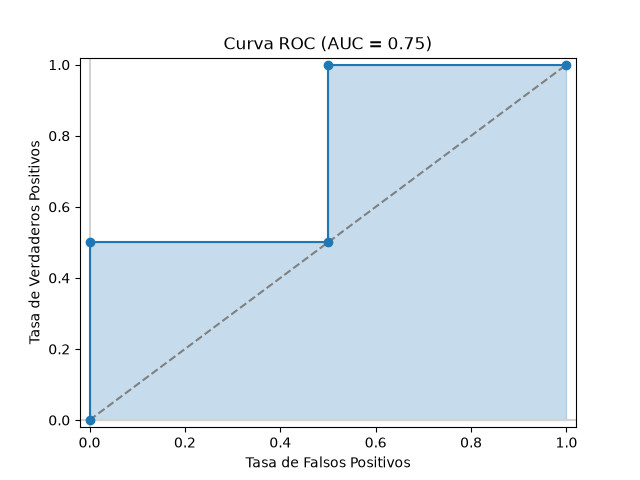